# 4 site exact solutions - straddling

Created 21/05/2025

Objectives:
* Find exact solutions with boundary operators of width 4. This time take support to be straddling the symmetry boundary, two sites interior and two sites exterior.

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [3]:
from itertools import chain, combinations, product
from collections import defaultdict
from functools import reduce
import re

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [5]:
from tqdm import tqdm

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [7]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_200_site"

In [8]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

In [9]:
t_parameters = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))

In [10]:
psi_dict = dict()

In [11]:
for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_1
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_2
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b+1] = quimb_psi

# Definitons

In [12]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [13]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [14]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

'\nnpc_I = to_npc_array(np_I)\nnpc_X = to_npc_array(np_X)\nnpc_Y = to_npc_array(np_Y)\nnpc_Z = to_npc_array(np_Z)\n'

In [86]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, left_most_symmetry_site,
                         num_symmetry_sites, num_interior_boundary_sites,
                         num_exterior_boundary_sites, antilinear=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    left_exterior_boundary_sites = list(range(
        left_most_symmetry_site - num_exterior_boundary_sites,
        left_most_symmetry_site
    ))

    left_interior_boundary_sites = list(range(
        left_most_symmetry_site,
        left_most_symmetry_site + num_interior_boundary_sites
    ))

    left_boundary_sites = (
        left_exterior_boundary_sites
        + left_interior_boundary_sites
    )

    right_most_symmetry_site = left_most_symmetry_site + num_symmetry_sites - 1

    right_interior_boundary_sites = list(range(
        right_most_symmetry_site - num_interior_boundary_sites+1,
        right_most_symmetry_site+1
    ))

    right_exterior_boundary_sites = list(range(
        right_most_symmetry_site+1,
        right_most_symmetry_site + num_exterior_boundary_sites+1
    ))
    
    right_boundary_sites = (
        right_interior_boundary_sites
        + right_exterior_boundary_sites
    )

    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(left_most_symmetry_site-num_exterior_boundary_sites)),
        'middle': list(range(
            left_most_symmetry_site+num_interior_boundary_sites,
            right_most_symmetry_site - num_interior_boundary_sites+1
        )),
        'right': list(range(
            right_most_symmetry_site + num_exterior_boundary_sites+1,
            quimb_psi.L
        ))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    tnc = tn.contract()

    """
    fuse_maps = [
        ('k_left_in', (f'k{i}' for i in left_interior_boundary_sites)),
        ('k_left_out', (f'k{i}' for i in left_exterior_boundary_sites)),
        ('b_left_in', (f'b{i}' for i in left_interior_boundary_sites)),
        ('b_left_out', (f'b{i}' for i in left_exterior_boundary_sites)),
        ('k_right_in', (f'k{i}' for i in right_interior_boundary_sites)),
        ('k_right_out', (f'k{i}' for i in right_exterior_boundary_sites)),
        ('b_right_in', (f'b{i}' for i in right_interior_boundary_sites)),
        ('b_right_out', (f'b{i}' for i in right_exterior_boundary_sites)),
    ]
    """

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [61]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    left_inds = [
        'k_left_in',
        'k_left_out',
        'b_left_in',
        'b_left_out'
    ]

    right_inds=[
        'k_right_in',
        'k_right_out',
        'b_right_in',
        'b_right_out'
    ]
    # Hard code warning
    u_left = qtn.tensor_builder.rand_tensor(
        (4, 4, 4, 4),
        inds=left_inds,
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (4, 4, 4, 4),
        inds=right_inds,
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds=right_inds)
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds=left_inds)

    return (u_left, u_right), scores

## SPT functions

In [17]:
def calculate_proj_rep_phase(state_g, left_schmidt_values_g, unitary_h,
                             state_gh,
                             left_environment,
                             max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM):
    prod_state, _ = multiply_stacked_unitaries_against_mps(
        unitary_h,
        state_g,
        left_schmidt_values_g,
        max_virtual_bond_dim
    )

    exp = inner_product_b_tensors(prod_state, state_gh, left_environment)

    return exp/(np.abs(exp))

In [18]:
def get_proj_rep_phases(mps_tensors, left_schmidt_values, unitaries,
                        left_environment):
    mps_dict = {
        k: v for k, v in zip(symmetry_labels[1:], mps_tensors)
    }

    schmidt_vals_dict = {
        k: v for k, v in zip(symmetry_labels[1:], left_schmidt_values)
    }

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()

    for a, b, c in group_products:
        phase = calculate_proj_rep_phase(
            mps_dict[a],
            schmidt_vals_dict[a],
            unitaries_dict[b],
            mps_dict[c],
            left_environment,
            max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM
        )

        out_phases.append(phase)

    return out_phases

In [19]:
def get_right_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_right_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_right_side_left_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.right_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].right_side_left_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

In [20]:
def get_left_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_left_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_left_side_right_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.left_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].left_side_right_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

## SPT extraction functions

In [21]:
# Boolean indicates if the symmetry is anti-linear or not.
symmetry_actions = [
    ([np_I, np_I], False),
    ([np_X, np_I], False),
    ([np_I, np_X], True),
    ([np_X, np_X], True)
]

In [22]:
symmetry_labels = [
    'I-I',
    'X-I',
    'I-XK',
    'X-XK'
]

In [23]:
identity_element = 'I-I'

In [24]:
e, a, b, c = symmetry_labels

In [25]:
group_products = [
    (a, a, e),
    (b, b, e),
    (c, c, e),
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (b, c, a),
    (c, b, a),
]

In [26]:
group_products_dict = {
    (a,b): c for a,b,c in group_products
}

In [27]:
def multi_kron(arrays):
    return reduce(lambda X, Y: np.kron(X, Y), arrays)

In [28]:
symmetry_actions_dict = {
    'I-I': (np.identity(16), False),
    'X-I': (multi_kron([np_X, np_I, np_X, np_I]), False),
    'I-XK': (multi_kron([np_I, np_X, np_I, np_X]), True),
    'X-XK': (multi_kron([np_X, np_X, np_X, np_X]), True)
}

In [29]:
antilinear_dict = {
    e: False,
    a: False,
    b: True,
    c: True
}

In [30]:
def relabel_mpo(mpo, k_label, b_label):
    site_locs = [
        int(k[1:]) for k in mpo.tag_map
        if bool(re.search(regex_p, k))
    ]

    k_in_indices = [f'k{i}' for i in site_locs]
    j_in_indices = [f'b{i}' for i in site_locs]

    k_out_indices = [f'{k_label}{i}' for i in site_locs]
    j_out_indices = [f'{b_label}{i}' for i in site_locs]

    mapping = dict(
        chain(
            zip(k_in_indices, k_out_indices),
            zip(j_in_indices, j_out_indices)
        )
    )

    mpo.reindex(mapping, inplace=True)

In [31]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    m = (u_gh.conj().T) @ u_h @ u_g @ rho
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [32]:
np_I_4 = np.identity(16)

In [33]:
# Duplicate definition here...!
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

In [34]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_exterior_proj_rep_phase_kapustin_rule(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ m_h
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [35]:
# Duplicate definition here...!
def get_exterior_proj_rep_phases_kapustin_rule(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_exterior_proj_rep_phase_kapustin_rule(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

In [36]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_interior_proj_rep_phase(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ g_sym
        @ m_h
        @ (g_sym.conj().T)
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [37]:
# Duplicate definition here...!
def get_interior_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_interior_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

## Cocycle checks

In [38]:
def omega_lookup(proj_rep_phases_array, g, h):
    if (g == identity_element) or (h == identity_element):
        return np.ones(shape=proj_rep_phases_array.shape[:-1], dtype=np.complex128)
    index = next(
        i for i, (a,b,c) in enumerate(group_products)
        if (a,b) == (g,h)
    )

    return proj_rep_phases_array[..., index]

In [39]:
def cocyle_check(proj_rep_phases_array, g, h, k, twisted=False):
    X = omega_lookup(proj_rep_phases_array, h, k)
    if antilinear_dict[g] and twisted:
        X = X.conj()

    cocycle_array = (
        X*omega_lookup(proj_rep_phases_array, g, group_products_dict[(h,k)])
        /(
            omega_lookup(proj_rep_phases_array, g, h)
            *omega_lookup(proj_rep_phases_array, group_products_dict[(g,h)], k)
        )
    )

    return cocycle_array

In [40]:
def check_cocycle_equation(proj_rep_phases_array, twisted=False):
    arrays = list()

    for g,h,k in product(symmetry_labels[1:], repeat=3):
        arrays.append(cocyle_check(proj_rep_phases_array, g,h,k, twisted))

    out = np.stack(arrays, axis=-1)

    return out

# Calculate boundary operators

In [87]:
num_interior_boundary_sites=2
num_exterior_boundary_sites=2
left_most_symmetry_site=60
num_symmetry_sites=80

symmetry_sites = list(range(
    left_most_symmetry_site,
    left_most_symmetry_site+num_symmetry_sites
))

In [88]:
num_iterations = 3

In [91]:
results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            left_most_symmetry_site,
            num_symmetry_sites,
            num_interior_boundary_sites,
            num_exterior_boundary_sites,
            antilinear=antilinear
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        results_dict[(k1, k2)] = (u_left, u_right), scores

  0%|                                                                                                                          | 0/21 [00:05<?, ?it/s]


ValueError: Wrong number of inds, ('k_right_in', 'k_right_out', 'b_right_in', 'b_right_out'), supplied for array of shape (4, 4, 4, 4, 16, 16, 16, 16).

### Check results

In [63]:
t_params = np.round(np.linspace(0, 2, 21), 1)

In [64]:
t_params

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [65]:
scores = list()
for t in t_params:

    scores.append([results_dict[(t, i)][1][-1] for i in [1,2,3]])

scores = np.array(scores)

In [66]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

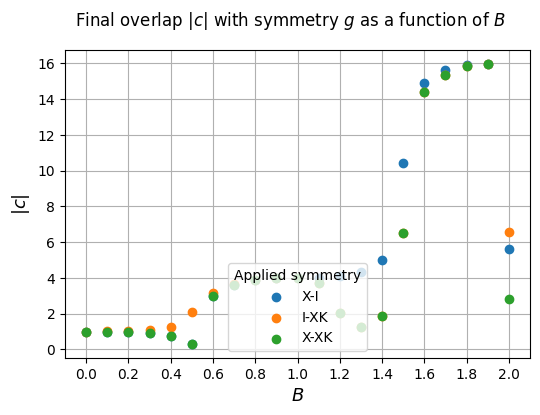

In [67]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

Why are the boundary operator scores so good...?

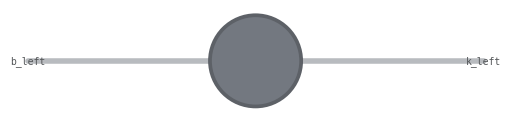

In [59]:
results_dict[(0,1)][0][0].draw()

In [47]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        left_most_symmetry_site,
        num_interior_boundary_sites,
        num_exterior_boundary_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:22<00:00,  1.07s/it]


In [48]:
proj_rep_phases = np.array(proj_rep_phases)

In [49]:
proj_rep_phases.shape

(21, 2, 9)

In [50]:
np.round(proj_rep_phases, 3)

array([[[ 0.982-0.188j, -0.382-0.924j, -0.758+0.653j,  0.659+0.752j,
          0.659+0.752j,  0.507-0.862j,  0.507-0.862j, -0.947-0.322j,
         -0.947-0.322j],
        [ 0.982+0.188j, -0.382+0.924j, -0.758-0.653j,  0.659-0.752j,
          0.659-0.752j,  0.507+0.862j,  0.507+0.862j, -0.947+0.322j,
         -0.947+0.322j]],

       [[-0.733-0.681j,  0.128-0.992j, -0.871-0.491j,  0.823-0.567j,
          0.823-0.567j, -0.217-0.976j, -0.217-0.976j,  0.668-0.744j,
          0.668-0.744j],
        [-0.733+0.681j,  0.128+0.992j, -0.871+0.491j,  0.823+0.567j,
          0.823+0.567j, -0.217+0.976j, -0.217+0.976j,  0.668+0.744j,
          0.668+0.744j]],

       [[-0.66 -0.751j,  0.021-1.j   , -0.657-0.754j,  0.713-0.701j,
          0.713-0.701j,  0.056-0.998j,  0.056-0.998j,  0.716-0.698j,
          0.716-0.698j],
        [-0.66 +0.751j,  0.021+1.j   , -0.657+0.754j,  0.713+0.701j,
          0.713+0.701j,  0.056+0.998j,  0.056+0.998j,  0.716+0.698j,
          0.716+0.698j]],

       [[ 1.   -

In [56]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [59]:
np.max(np.abs(cocycle_check_array - 1))

0.06948518791918147

In [60]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [61]:
np.max(np.abs(cocycle_check_array - 1))

1.9999873524305214

In [62]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        left_most_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_exterior_proj_rep_phases_kapustin_rule(left_rdm, left_unitaries)
    right_phases = get_exterior_proj_rep_phases_kapustin_rule(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:23<00:00,  1.10s/it]


In [66]:
proj_rep_phases = np.array(proj_rep_phases)

In [67]:
proj_rep_phases.shape

(21, 2, 9)

In [68]:
np.round(proj_rep_phases, 3)

array([[[ 0.982-0.188j, -1.   -0.j   ,  1.   +0.j   ,  0.659+0.752j,
         -0.507-0.862j,  0.507-0.862j, -0.659+0.752j,  0.507+0.862j,
         -0.659+0.752j],
        [ 0.982+0.188j, -1.   +0.j   ,  1.   -0.j   ,  0.659-0.752j,
         -0.507+0.862j,  0.507+0.862j, -0.659-0.752j,  0.507-0.862j,
         -0.659-0.752j]],

       [[-0.733-0.681j, -1.   +0.j   ,  1.   -0.j   ,  0.823-0.567j,
          0.217-0.976j, -0.217-0.976j, -0.823-0.567j, -0.217+0.976j,
         -0.823-0.567j],
        [-0.733+0.681j, -1.   -0.j   ,  1.   +0.j   ,  0.823+0.567j,
          0.217+0.976j, -0.217+0.976j, -0.823+0.567j, -0.217-0.976j,
         -0.823+0.567j]],

       [[-0.66 -0.751j, -1.   +0.j   ,  1.   -0.j   ,  0.713-0.701j,
         -0.056-0.998j,  0.056-0.998j, -0.713-0.701j,  0.056+0.998j,
         -0.713-0.701j],
        [-0.66 +0.751j, -1.   -0.j   ,  1.   +0.j   ,  0.713+0.701j,
         -0.056+0.998j,  0.056+0.998j, -0.713+0.701j,  0.056-0.998j,
         -0.713+0.701j]],

       [[ 1.   -

In [73]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [74]:
np.max(np.abs(cocycle_check_array - 1))

1.9999655284442917

In [77]:
cocycle_check_array.shape

(21, 2, 27)

In [76]:
np.round(cocycle_check_array, 3)

array([[[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.131-0.991j, -0.131-0.991j,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.131+0.991j, -0.131+0.991j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          0.356+0.934j,  0.356+0.934j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          0.356-0.934j,  0.356-0.934j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          0.017+1.j   ,  0.017+1.j   ,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          0.017-1.j   ,  0.017-1.j   ,  1.   +0.j   ]],

       ...,

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.43 +0.903j, -0.43 +0.903j,  1.   -0.j   ],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.43 -0.903j, -0.43 -0.903j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
        

In [78]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [79]:
np.round(cocycle_check_array, 3)

array([[[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   ,  1.   +0.j   ,  1.   -0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   -0.j   ,  1.   -0.j   ,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   ]],

       ...,

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   , -0.304+0.953j, -0.304+0.953j],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          1.   +0.j   ,  0.964-0.268j,  0.964-0.268j]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
        

In [80]:
np.max(np.abs(cocycle_check_array - 1))

1.9979095450266238

## Interior

In [81]:
interior_results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            left_most_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear,
            interior=True
            
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        interior_results_dict[(k1, k2)] = (u_left, u_right), scores

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:11<00:00,  3.39s/it]


In [91]:
interior_scores = list()
for t in t_params:

    interior_scores.append([interior_results_dict[(t, i)][1][-1] for i in [1,2,3]])

interior_scores = np.array(interior_scores)

In [92]:
interior_scores

array([[1.        , 1.        , 1.        ],
       [0.99380799, 1.        , 0.99380799],
       [0.96824589, 1.        , 0.96824589],
       [0.90351332, 1.        , 0.90351332],
       [0.74568893, 1.        , 0.74568893],
       [0.1097449 , 1.        , 0.10941196],
       [0.74594755, 0.99999823, 0.74594666],
       [0.90351763, 1.        , 0.90351763],
       [0.96824592, 1.        , 0.96824592],
       [0.99380799, 1.        , 0.99380799],
       [1.        , 1.        , 1.        ],
       [1.        , 0.99855959, 0.99855959],
       [1.        , 0.99241536, 0.99241536],
       [1.        , 0.96745072, 0.96745072],
       [1.        , 0.91187853, 0.91187853],
       [1.        , 0.40402041, 0.40402041],
       [1.        , 0.94737346, 0.94737346],
       [1.        , 0.98839352, 0.98839352],
       [1.        , 0.9976646 , 0.9976646 ],
       [1.        , 0.99968356, 0.99968356],
       [1.        , 1.        , 1.        ]])

In [93]:
interior_scores - exterior_scores

array([[ 4.44089210e-16, -2.22044605e-16,  0.00000000e+00],
       [ 1.54321000e-14,  1.77635684e-15,  1.57651669e-14],
       [-1.84041671e-12,  1.11022302e-15, -1.84074977e-12],
       [ 5.81312776e-13, -1.33226763e-15,  5.82645043e-13],
       [-2.19280618e-06, -1.55431223e-15, -2.19280618e-06],
       [ 1.17527628e-02,  1.77635684e-15,  1.22488427e-02],
       [-7.47302642e-06,  3.55271368e-15, -7.67245235e-06],
       [ 3.81960560e-07,  7.98973121e-09,  3.88039153e-07],
       [ 2.40089948e-09,  9.99200722e-16,  2.40090547e-09],
       [ 1.95310434e-12, -1.33226763e-15,  1.95277128e-12],
       [-2.22044605e-16,  3.33066907e-16,  1.11022302e-16],
       [ 1.55431223e-15,  1.00519988e-06,  1.00519988e-06],
       [-4.44089210e-16,  5.53299993e-04,  5.53299993e-04],
       [ 1.11022302e-15, -4.84358027e-03, -4.84358027e-03],
       [-4.44089210e-16, -6.47037180e-03, -6.47037180e-03],
       [ 1.01030295e-13, -3.81842805e-03, -3.81842103e-03],
       [-1.66533454e-15, -1.01086385e-02

Very small difference...

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

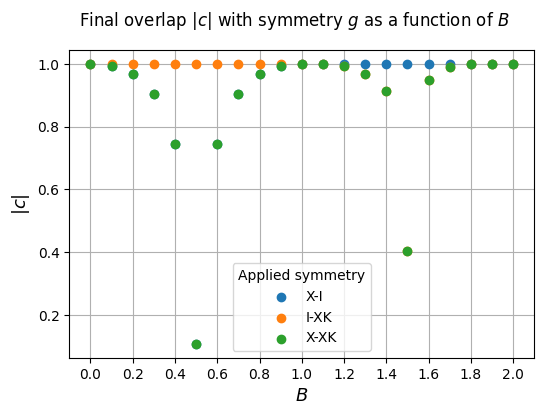

In [94]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        interior_scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [95]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        left_most_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [interior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]
    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]

    left_phases = get_interior_proj_rep_phases(
        left_rdm,
        left_unitaries
    )
    right_phases = get_interior_proj_rep_phases(
        right_rdm,
        right_unitaries
    )

    proj_rep_phases.append([left_phases, right_phases])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:23<00:00,  1.11s/it]


In [96]:
proj_rep_phases = np.array(proj_rep_phases)

In [97]:
proj_rep_phases.shape

(21, 2, 9)

In [98]:
proj_rep_phases.shape

(21, 2, 9)

In [99]:
np.round(proj_rep_phases, 3)

array([[[ 0.734-0.679j, -1.   -0.j   ,  1.   -0.j   ,  0.149+0.989j,
          0.563-0.827j, -0.563-0.827j, -0.149+0.989j, -0.563+0.827j,
         -0.149+0.989j],
        [ 0.734+0.679j, -1.   -0.j   ,  1.   +0.j   ,  0.149-0.989j,
          0.563+0.827j, -0.563+0.827j, -0.149-0.989j, -0.563-0.827j,
         -0.149-0.989j]],

       [[ 0.999+0.042j, -1.   -0.j   ,  1.   +0.j   ,  0.314-0.949j,
         -0.275+0.962j,  0.275+0.962j, -0.314-0.949j,  0.275-0.962j,
         -0.314-0.949j],
        [ 0.999-0.042j, -1.   -0.j   ,  1.   +0.j   ,  0.314+0.949j,
         -0.275-0.962j,  0.275-0.962j, -0.314+0.949j,  0.275+0.962j,
         -0.314+0.949j]],

       [[ 0.233+0.973j, -1.   +0.j   ,  1.   -0.j   , -0.808+0.589j,
         -0.385-0.923j,  0.385-0.923j,  0.808+0.589j,  0.385+0.923j,
          0.808+0.589j],
        [ 0.233-0.973j, -1.   -0.j   ,  1.   -0.j   , -0.808-0.589j,
         -0.385+0.923j,  0.385+0.923j,  0.808-0.589j,  0.385-0.923j,
          0.808-0.589j]],

       [[ 0.424-

In [100]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [101]:
np.max(np.abs(cocycle_check_array - 1))

1.9943376932982104

In [102]:
cocycle_check_array.shape

(21, 2, 27)

In [103]:
np.round(cocycle_check_array, 3)

array([[[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.956-0.294j, -0.956-0.294j,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.956+0.294j, -0.956+0.294j,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.802+0.597j, -0.802+0.597j,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   +0.j   , ...,
         -0.802-0.597j, -0.802-0.597j,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          0.307+0.952j,  0.307+0.952j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          0.307-0.952j,  0.307-0.952j,  1.   +0.j   ]],

       ...,

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.715+0.699j, -0.715+0.699j,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.715-0.699j, -0.715-0.699j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
        

In [104]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [105]:
np.round(cocycle_check_array, 3)

array([[[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.-0.j, 1.+0.j],
        [1.+0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j]],

       [[1.+0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j],
        [1.+0.j, 1.-0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j]],

       [[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.+0.j],
        [1.-0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j]],

       ...,

       [[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j],
        [1.+0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.+0.j, 1.+0.j]],

       [[1.-0.j, 1.+0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j],
        [1.+0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.+0.j, 1.+0.j]],

       [[1.-0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j],
        [1.-0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j]]])

In [106]:
np.max(np.abs(cocycle_check_array - 1))

0.00020976590534784134

# Conclusion
Exterior defect operators obey an untwisted cocycle equation, while interior defect operators obey a twisted cocycle equation...